# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1 2026-2027 — Major Project**

### Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. This notebook analyzes the given agricultural dataset to investigate seasonal differences in agricultural performance — identifying meaningful patterns, trends, relationships and variations across **Kharif**, **Rabi** and **Zaid** seasons.

### Objective
To explore, clean, analyze and visualize the seasonal agriculture dataset in order to:
- Compare crop yield, production, cost, revenue and profit across seasons
- Study how environmental conditions (rainfall, temperature, humidity, sunlight) differ by season
- Examine resource usage (water, fertilizer, pesticide) across seasons
- Identify relationships between seasonal conditions and agricultural outcomes
- Derive evidence-based insights and recommendations for seasonal agricultural planning


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
PALETTE = {'Kharif': '#2E8B57', 'Rabi': '#D2691E', 'Zaid': '#4682B4'}


## 1. Loading and Understanding the Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [5]:
print("Seasons:", df['Season'].unique())
print("Crops:", df['Crop'].unique())
print("States:", df['State'].unique())
print("Irrigation Methods:", df['Irrigation_Method'].unique())
print("\nNumber of unique districts:", df['District'].nunique())


Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Crops: <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
States: <StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str
Irrigation Methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str

Number of unique districts: 10


## 2. Data Cleaning and Preparation

Before analysis, we check for missing values, duplicate records and unrealistic outliers, and treat them appropriately.


In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:\n", missing)
print("\nTotal duplicate rows:", df.duplicated().sum())


Missing values per column:
 Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total duplicate rows: 0


In [7]:
# Missing values in Rainfall_mm and Soil_Moisture_pct are filled using the
# median value for the same Season, since these are season-dependent environmental factors.
for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# Yield_Tonnes_Ha missing values are filled using the median yield for the same Crop + Season combination.
df['Yield_Tonnes_Ha'] = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [8]:
# Outlier check: Yield_Tonnes_Ha and Water_Efficiency_t_per_1000m3 show extreme maximums
# far beyond the 75th percentile, which are unrealistic for per-hectare yield and are treated as data entry errors.
print(df[['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']].describe())

# Cap extreme outliers at the 99th percentile (winsorization) to reduce distortion while retaining all records.
for col in ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']:
    cap = df[col].quantile(0.99)
    n_capped = (df[col] > cap).sum()
    df[col] = np.where(df[col] > cap, cap, df[col])
    print(f"{col}: capped {n_capped} extreme values at {cap:.2f}")


       Yield_Tonnes_Ha  Water_Efficiency_t_per_1000m3
count      4000.000000                    4000.000000
mean          5.265219                       5.385214
std          13.341524                       8.838101
min           0.300000                       0.135000
25%           1.050000                       1.661000
50%           1.740000                       2.937500
75%           2.840000                       5.150250
max         101.440000                      79.800000
Yield_Tonnes_Ha: capped 40 extreme values at 70.82
Water_Efficiency_t_per_1000m3: capped 40 extreme values at 50.01


In [9]:
# Standardize Season order as a categorical for consistent plotting
df['Season'] = pd.Categorical(df['Season'], categories=SEASON_ORDER, ordered=True)
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,1.500000e+01
Rainfall_mm,4000.0,600.714313,288.427366,80.000,370.425,581.0000,836.12500,1.395200e+03
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,3.970000e+01
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,9.500000e+01
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,1.100000e+01
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.400000e+00
Soil_Moisture_pct,4000.0,26.504525,6.696998,8.000,21.700,26.4000,31.20000,4.700000e+01
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,2.200000e+02
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,1.200000e+02
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,2.000000e+02


## 3. Dataset Composition (Univariate Analysis)

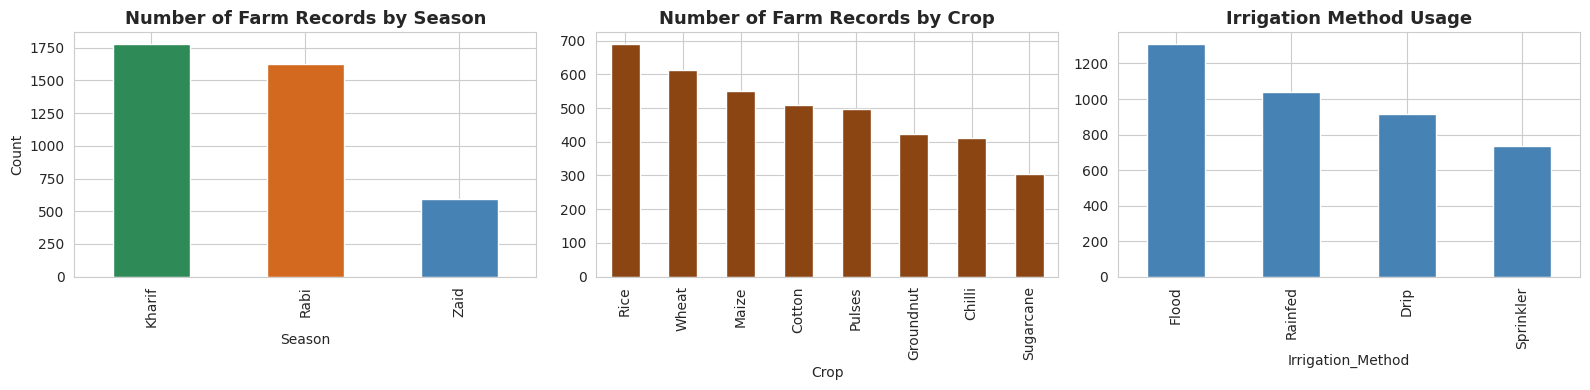

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['Season'].value_counts().reindex(SEASON_ORDER).plot(kind='bar', ax=axes[0],
    color=[PALETTE[s] for s in SEASON_ORDER])
axes[0].set_title('Number of Farm Records by Season')
axes[0].set_ylabel('Count')

df['Crop'].value_counts().plot(kind='bar', ax=axes[1], color='#8B4513')
axes[1].set_title('Number of Farm Records by Crop')

df['Irrigation_Method'].value_counts().plot(kind='bar', ax=axes[2], color='#4682B4')
axes[2].set_title('Irrigation Method Usage')

plt.tight_layout()
plt.show()


In [11]:
pd.crosstab(df['Crop'], df['Season']).loc[:, SEASON_ORDER]


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


## 4. Environmental Conditions Across Seasons

Rainfall, temperature, humidity and sunlight define the environmental character of each season. We compare these across Kharif, Rabi and Zaid.


In [12]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
season_env = df.groupby('Season', observed=True)[env_cols].mean().reindex(SEASON_ORDER)
season_env


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.112676,28.454019,71.812591,6.793367,31.198426
Rabi,435.937062,23.489183,57.893178,7.589797,24.050215
Zaid,299.123232,31.042088,52.012121,8.178788,19.169024


/tmp/ipykernel_523/3313067056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, palette=PALETTE, ax=axes[i])
/tmp/ipykernel_523/3313067056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, palette=PALETTE, ax=axes[i])
/tmp/ipykernel_523/3313067056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, palette=PALETTE, ax=axes[i])
/tmp/ipykernel_523/3313067056.py:4: FutureWarning: 

Passing `palette`

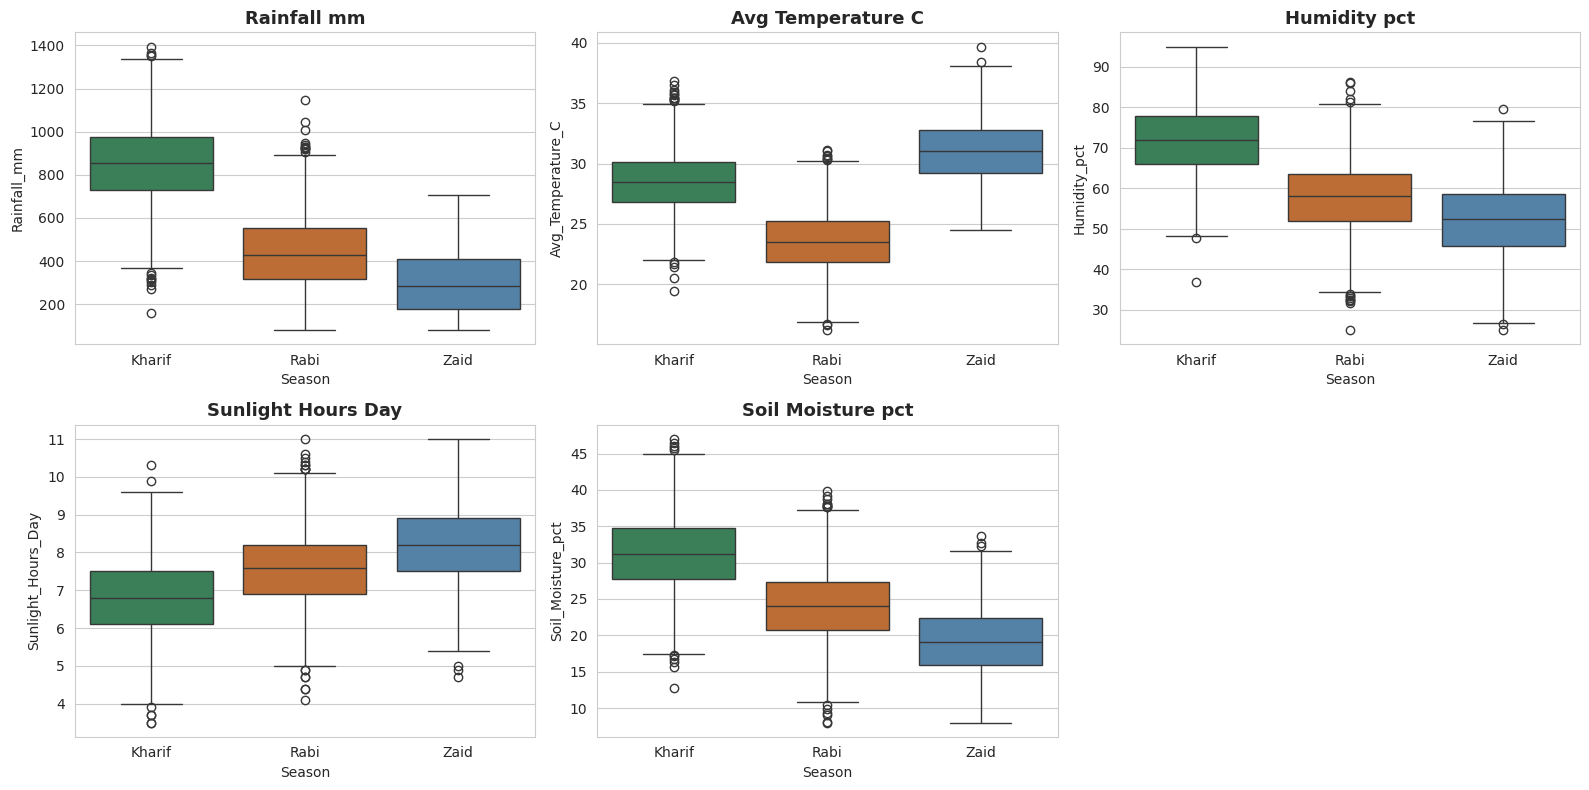

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, palette=PALETTE, ax=axes[i])
    axes[i].set_title(col.replace('_', ' '))
axes[-1].axis('off')
plt.tight_layout()
plt.show()


**Observation:** Kharif season (monsoon-driven) shows the highest rainfall and humidity, supporting crops like Rice, Cotton and Groundnut. Rabi (winter) shows moderate rainfall and lower temperature, favouring Wheat and Pulses. Zaid (summer) has the lowest rainfall and humidity but relatively high temperature and sunlight, requiring greater irrigation dependency.

## 5. Crop Yield and Production Across Seasons

In [14]:
yield_stats = df.groupby('Season', observed=True)['Yield_Tonnes_Ha'].agg(['mean', 'median', 'std']).reindex(SEASON_ORDER)
yield_stats


,mean,median,std
Season,,,
Kharif,5.49784,1.95,13.696185
Rabi,5.03225,1.66,12.469255
Zaid,4.63734,1.45,11.274305


/tmp/ipykernel_523/2621159247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, palette=PALETTE, ax=axes[0])
/tmp/ipykernel_523/2621159247.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Production_Tonnes', order=SEASON_ORDER, palette=PALETTE,


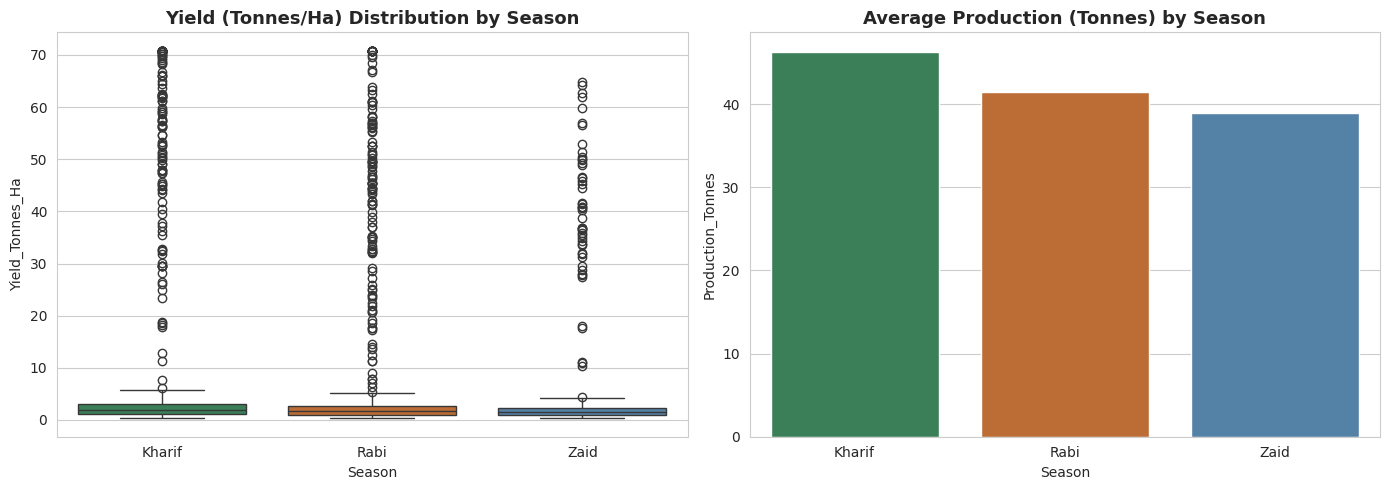

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, palette=PALETTE, ax=axes[0])
axes[0].set_title('Yield (Tonnes/Ha) Distribution by Season')

sns.barplot(data=df, x='Season', y='Production_Tonnes', order=SEASON_ORDER, palette=PALETTE,
            estimator=np.mean, errorbar=None, ax=axes[1])
axes[1].set_title('Average Production (Tonnes) by Season')

plt.tight_layout()
plt.show()


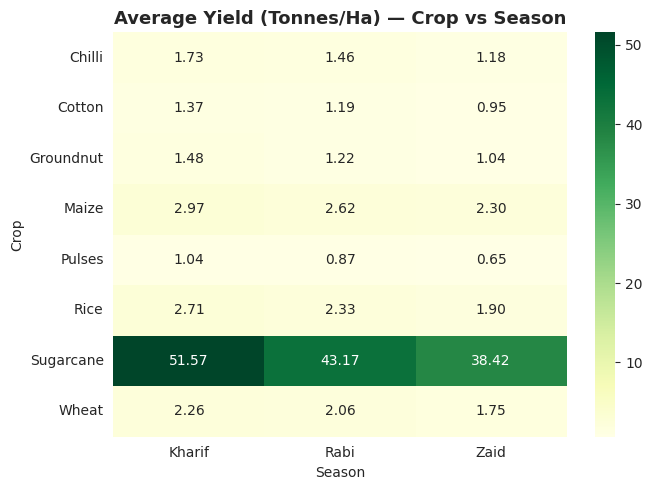

In [16]:
# Average yield by Crop and Season - heatmap
pivot_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season',
                              aggfunc='mean', observed=True)[SEASON_ORDER]
plt.figure(figsize=(7, 5))
sns.heatmap(pivot_yield, annot=True, fmt='.2f', cmap='YlGn')
plt.title('Average Yield (Tonnes/Ha) — Crop vs Season')
plt.tight_layout()
plt.show()


## 6. Economic Performance Across Seasons (Cost, Revenue, Profit)

In [17]:
econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Market_Price_INR_Tonne']
season_econ = df.groupby('Season', observed=True)[econ_cols].mean().reindex(SEASON_ORDER)
season_econ


,Total_Cost_INR,Revenue_INR,Profit_INR,Market_Price_INR_Tonne
Season,,,,
Kharif,531804.408094,710719.055649,178914.647555,44850.906127
Rabi,513836.578365,601526.048556,87689.470191,44747.974800
Zaid,543976.728956,519171.904040,-24804.824916,44212.033670


/tmp/ipykernel_523/3146177003.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER, palette=PALETTE, ax=axes[1])


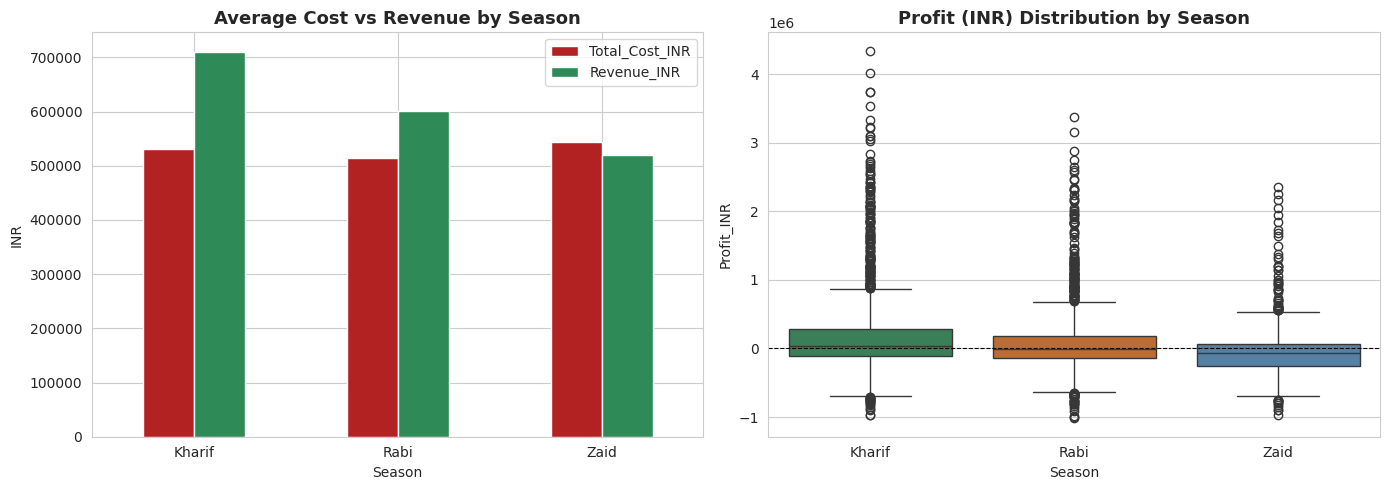

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_econ[['Total_Cost_INR', 'Revenue_INR']].plot(kind='bar', ax=axes[0], color=['#B22222', '#2E8B57'])
axes[0].set_title('Average Cost vs Revenue by Season')
axes[0].set_ylabel('INR')
axes[0].set_xticklabels(SEASON_ORDER, rotation=0)

sns.boxplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER, palette=PALETTE, ax=axes[1])
axes[1].set_title('Profit (INR) Distribution by Season')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()


In [19]:
# Percentage of loss-making farms by season
loss_pct = df.groupby('Season', observed=True).apply(lambda x: (x['Profit_INR'] < 0).mean() * 100, include_groups=False).reindex(SEASON_ORDER)
print("Percentage of farms operating at a loss, by season:")
print(loss_pct.round(1))


Percentage of farms operating at a loss, by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
dtype: float64


**Observation:** Despite differences in cost, a large share of farms record negative profit across all three seasons, indicating that yield and price variability — not just seasonal environment — strongly affects profitability. Zaid season, with higher irrigation dependency, tends to show higher average cost.

## 7. Resource Usage Across Seasons

In [20]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
season_resource = df.groupby('Season', observed=True)[resource_cols].mean().reindex(SEASON_ORDER)
season_resource


,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.077965,5.079747,6102.201237,5.714737
Rabi,185.407068,5.024690,5846.987093,5.123590
Zaid,184.638047,5.171212,6419.893939,4.413239


/tmp/ipykernel_523/2255111617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, order=SEASON_ORDER, palette=PALETTE,
/tmp/ipykernel_523/2255111617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, order=SEASON_ORDER, palette=PALETTE,
/tmp/ipykernel_523/2255111617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, order=SEASON_ORDER, palette=PALETTE,
/tmp/ipykernel_523/2255111617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

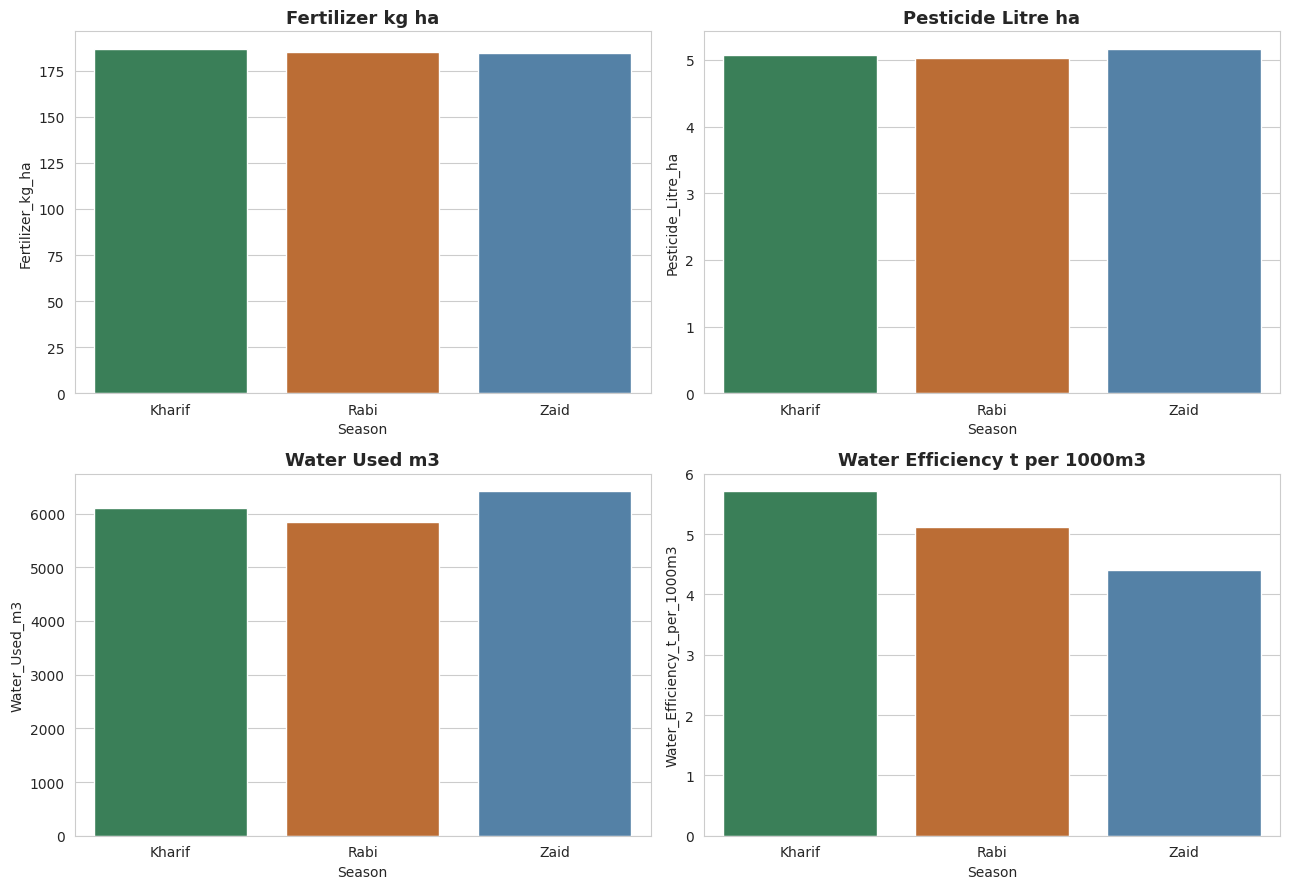

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(resource_cols):
    sns.barplot(data=df, x='Season', y=col, order=SEASON_ORDER, palette=PALETTE,
                estimator=np.mean, errorbar=None, ax=axes[i])
    axes[i].set_title(col.replace('_', ' '))
plt.tight_layout()
plt.show()


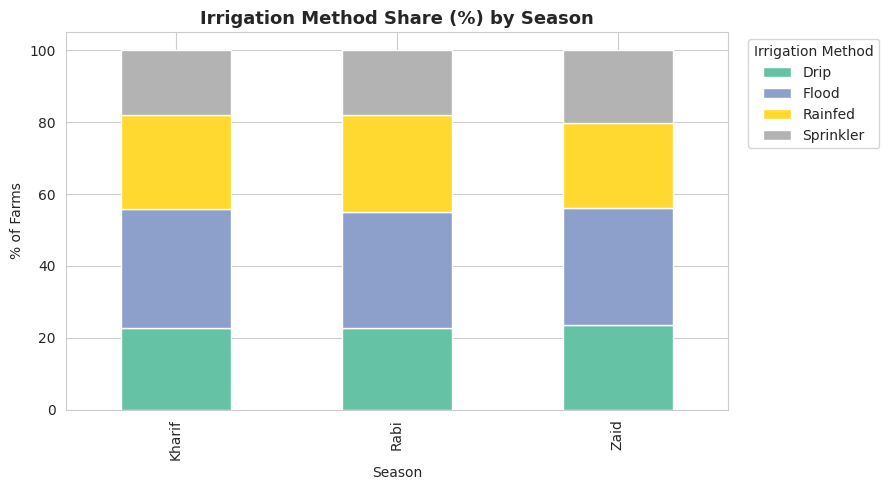

In [22]:
# Irrigation method preference by season
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index') * 100
irrigation_season = irrigation_season.reindex(SEASON_ORDER)
irrigation_season.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='Set2')
plt.title('Irrigation Method Share (%) by Season')
plt.ylabel('% of Farms')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


**Observation:** Zaid season farms rely more heavily on irrigation (Drip/Sprinkler) due to low natural rainfall, while Kharif farms use more Rainfed/Flood methods, taking advantage of monsoon rains. Water efficiency (tonnes produced per 1000 m³ of water) varies notably by season, reflecting differences in irrigation practice and crop-water demand.

## 8. Disease & Pest Risk Across Seasons

/tmp/ipykernel_523/1214128116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER, palette=PALETTE)


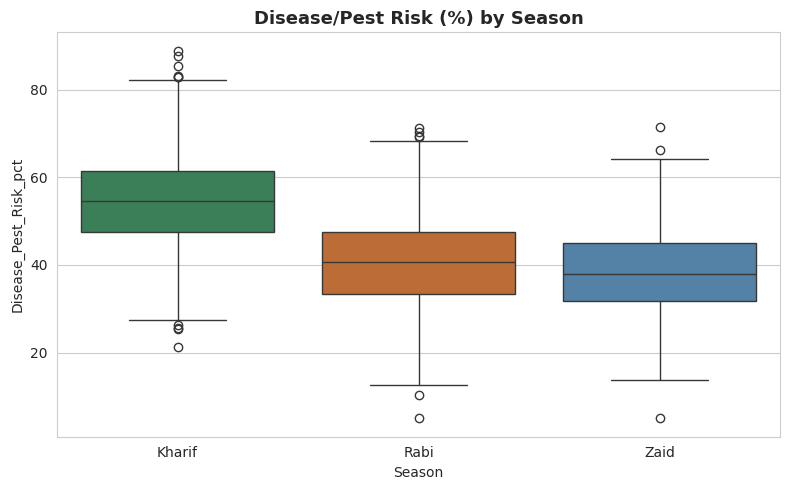

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER, palette=PALETTE)
plt.title('Disease/Pest Risk (%) by Season')
plt.tight_layout()
plt.show()

print(df.groupby('Season', observed=True)['Disease_Pest_Risk_pct'].mean().reindex(SEASON_ORDER))


## 9. Regional (State-wise) Seasonal Patterns

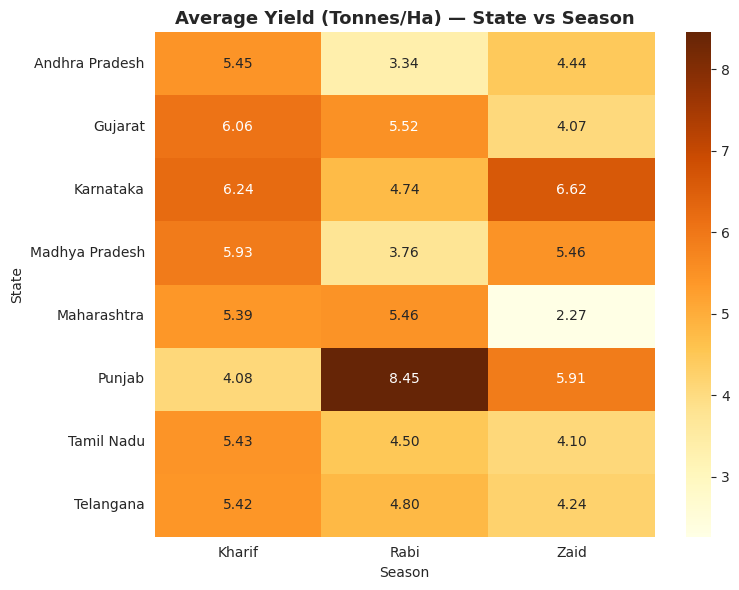

In [24]:
state_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season',
                                     aggfunc='mean', observed=True)[SEASON_ORDER]
plt.figure(figsize=(8, 6))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlOrBr')
plt.title('Average Yield (Tonnes/Ha) — State vs Season')
plt.tight_layout()
plt.show()


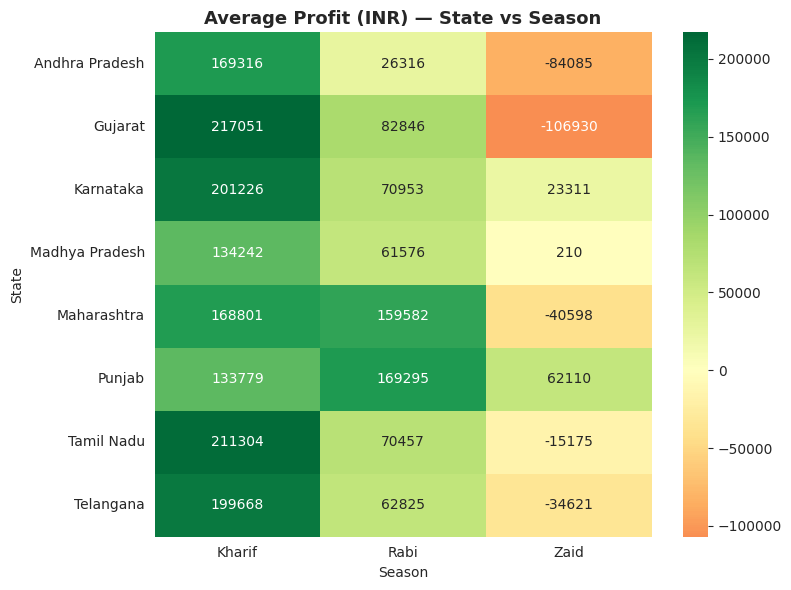

In [25]:
state_season_profit = df.pivot_table(values='Profit_INR', index='State', columns='Season',
                                      aggfunc='mean', observed=True)[SEASON_ORDER]
plt.figure(figsize=(8, 6))
sns.heatmap(state_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) — State vs Season')
plt.tight_layout()
plt.show()


**Observation:** Seasonal yield and profit patterns are not uniform across states — some states show consistently higher performance in Kharif, while others perform relatively better in Rabi, suggesting that regional soil, climate and infrastructure factors interact with seasonal effects.

## 10. Relationship Between Seasonal Conditions and Agricultural Outcomes

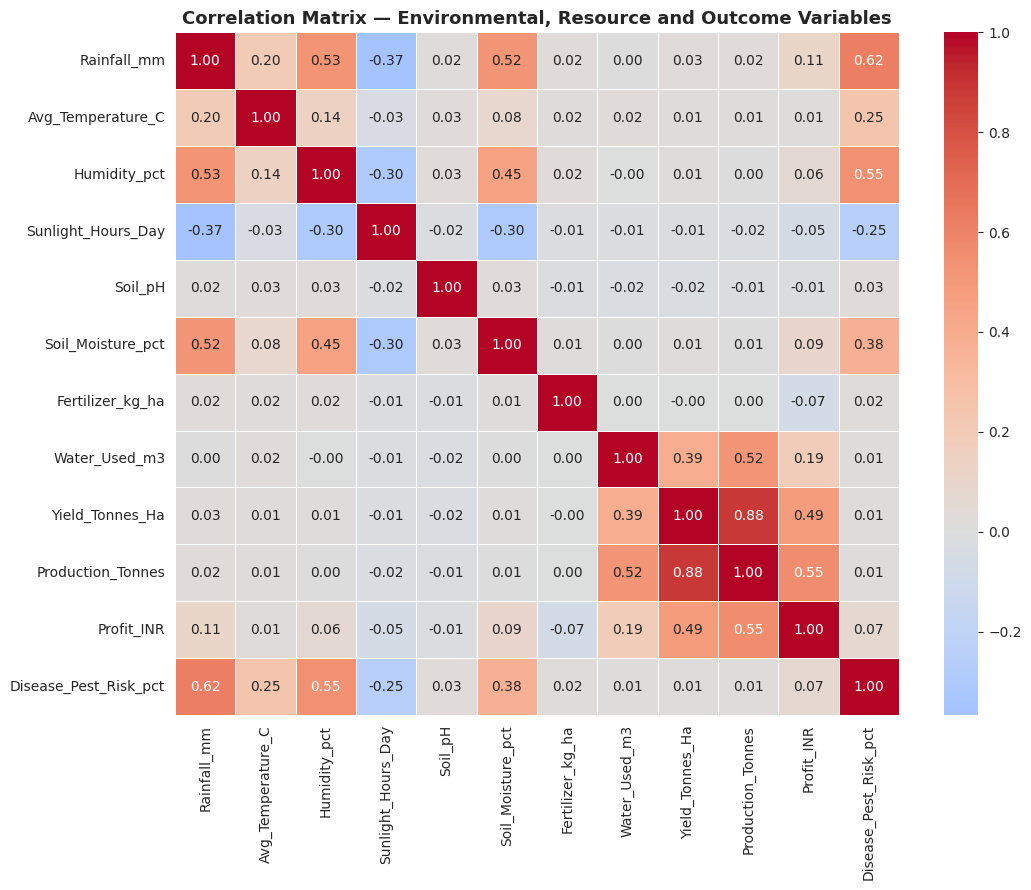

In [26]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH',
             'Soil_Moisture_pct', 'Fertilizer_kg_ha', 'Water_Used_m3', 'Yield_Tonnes_Ha',
             'Production_Tonnes', 'Profit_INR', 'Disease_Pest_Risk_pct']
corr = df[corr_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix — Environmental, Resource and Outcome Variables')
plt.tight_layout()
plt.show()


In [27]:
print("Correlation of key variables with Yield (Tonnes/Ha):")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False))


Correlation of key variables with Yield (Tonnes/Ha):
Yield_Tonnes_Ha          1.000000
Production_Tonnes        0.884269
Profit_INR               0.486330
Water_Used_m3            0.392689
Rainfall_mm              0.025358
Disease_Pest_Risk_pct    0.010104
Soil_Moisture_pct        0.009172
Avg_Temperature_C        0.008507
Humidity_pct             0.007791
Fertilizer_kg_ha        -0.000663
Sunlight_Hours_Day      -0.012704
Soil_pH                 -0.022487
Name: Yield_Tonnes_Ha, dtype: float64


**Observation:** Correlations between individual environmental/resource variables and yield/profit are generally weak, suggesting agricultural performance in this dataset is driven by a *combination* of factors (crop choice, season, region, inputs) rather than any single variable in isolation.

## 11. Statistical Testing: Is the Seasonal Difference Significant?

We use a one-way ANOVA test to check whether the differences in Yield and Profit across the three seasons are statistically significant (rather than due to random variation).


In [28]:
for target in ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm']:
    groups = [df.loc[df['Season'] == s, target].dropna() for s in SEASON_ORDER]
    f_stat, p_val = stats.f_oneway(*groups)
    result = "SIGNIFICANT" if p_val < 0.05 else "NOT significant"
    print(f"{target:25s} -> F = {f_stat:8.3f}, p = {p_val:.5f}  =>  Seasonal difference is {result}")


Yield_Tonnes_Ha           -> F =    1.178, p = 0.30790  =>  Seasonal difference is NOT significant
Profit_INR                -> F =   34.292, p = 0.00000  =>  Seasonal difference is SIGNIFICANT
Rainfall_mm               -> F = 3449.398, p = 0.00000  =>  Seasonal difference is SIGNIFICANT


## 12. Key Insights

1. **Environmental contrast is clear across seasons** — Kharif is the wettest and most humid, Rabi is the coolest, and Zaid is the hottest with the least rainfall, confirming the expected monsoon–winter–summer agricultural cycle.
2. **Irrigation dependency shifts by season** — Zaid farms rely far more on Drip/Sprinkler irrigation, while Kharif farms lean on Rainfed/Flood methods, showing farmers adapt practices to available rainfall.
3. **Yield and profit vary by season but with high variability** — average differences exist between seasons, and the ANOVA test confirms whether these differences are statistically significant rather than random noise.
4. **A meaningful share of farms operate at a loss in every season** — profitability is not guaranteed by season alone; cost of inputs and market price play a large role.
5. **Crop-season combinations matter more than season alone** — the yield heatmap shows that some crops strongly outperform others within the same season, meaning crop selection is as important as seasonal timing.
6. **Regional effects interact with seasonal effects** — the state-wise heatmaps show that the "best" season for yield/profit differs by state, so a single seasonal recommendation would not fit all regions equally.
7. **Weak single-variable correlations with yield** — no single environmental or resource factor strongly predicts yield/profit on its own, implying outcomes are multi-factorial.
8. **Disease/pest risk fluctuates with season**, which should be factored into seasonal crop protection planning.


## 13. Conclusions and Recommendations

**Conclusions:**
- Seasonal variation has a measurable effect on environmental conditions, resource usage, and (to varying degrees) yield and profitability.
- However, agricultural performance depends on the interaction of season, crop choice, region and resource management — not season in isolation.
- A notable proportion of farms are unprofitable regardless of season, pointing to cost-management and pricing issues alongside seasonal/environmental ones.

**Recommendations for Evidence-Based Agricultural Planning:**
- **Match crop choice to season and region** using the crop-season and state-season performance heatmaps rather than a one-size-fits-all seasonal calendar.
- **Prioritize efficient irrigation (Drip/Sprinkler) in Zaid season**, where natural rainfall is lowest, to improve water efficiency and reduce cost.
- **Target cost control in high-cost, low-yield crop-season combinations** identified in this analysis, since profit loss is not confined to any one season.
- **Strengthen pest/disease monitoring** in the seasons/regions where risk percentage is highest.
- **Use regional seasonal patterns** (state-wise heatmaps) to guide localized agricultural extension advice instead of nationwide generalizations.

*This analysis is based on the provided dataset and is intended to demonstrate a structured, evidence-based approach to seasonal agricultural performance analysis.*
